In [1]:
import torch
import torch.nn as nn
import math
import numpy as np
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict, OrderedDict
import pandas as pd
from typing import Union, List

class MathTokenizer:
    def __init__(self, base: int = 10):
        self.base = base
        self.special_tokens = ['[PAD]', '[SOS]', '[EOS]', '[UNK]']
        self.pad_token, self.sos_token, self.eos_token, self.unk_token = self.special_tokens

        
        self.digits = [str(i) for i in range(base)]

        # Vocabulary: special tokens + signs + digit symbols
        self.vocab = self.special_tokens + ['+', '-'] + self.digits
        self.token2id = {tok: idx for idx, tok in enumerate(self.vocab)}
        self.id2token = {idx: tok for tok, idx in self.token2id.items()}

    def _int_to_base(self, n: int) -> List[str]:
        """
        Convert a non-negative integer to its digit list in the current base.
        Returns a list of digit symbols (strings).
        """
        if n == 0:
            return [self.digits[0]]
        digits: List[str] = []
        while n > 0:
            digits.append(self.digits[n % self.base])
            n //= self.base
        return list(reversed(digits))

    def encode(self, sequence: Union[str, List[str]]) -> List[int]:
        """
        Encode a sequence (either a string of single-character tokens or a list of token strings)
        into token IDs, adding SOS and EOS.
        """
        if isinstance(sequence, str):
            # legacy: split string into single-character tokens
            tokens = [self.sos_token] + list(sequence) + [self.eos_token]
        else:
            # sequence is already a list of token strings
            tokens = [self.sos_token] + sequence + [self.eos_token]
        return [self.token2id.get(tok, self.token2id[self.unk_token]) for tok in tokens]

    def decode(self, ids: List[int]) -> List[str]:
        """
        Decode a list of token IDs to the sequence of token strings,
        stripping out special tokens.
        """
        tokens = [self.id2token.get(i, self.unk_token) for i in ids]
        # Remove special tokens
        return [tok for tok in tokens if tok not in (self.sos_token, self.eos_token, self.pad_token)]
    
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        position_enc = np.array(
        [
            [pos / np.power(10000, 2 * (j // 2) / d_model) for j in range(d_model)]
            for pos in range(max_len)
        ]
    )
        position_enc = torch.Tensor(position_enc)
        pe = torch.zeros_like(position_enc)
        pe[:, 0::2] = torch.FloatTensor(np.sin(position_enc[:, 0::2]))
        pe[:, 1::2] = torch.FloatTensor(np.cos(position_enc[:, 1::2]))
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        return x + self.pe[:x.size(1)]

class GCDTransformer(nn.Module):
    def __init__(self, tokenizer, d_model=128, nhead=8, num_layers=3, max_length=512, dropout=0.1):
        super().__init__()
        self.tokenizer = tokenizer
        self.vocab_size = len(tokenizer.vocab)
        
        self.embedding = nn.Embedding(self.vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model, max_length)
        
        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_layers,
            num_decoder_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        
        self.fc_out = nn.Linear(d_model, self.vocab_size)
        self.pad_id = tokenizer.token2id[tokenizer.pad_token]

    def forward(self, src, tgt):
        # src: (batch_size, src_len)
        # tgt: (batch_size, tgt_len)
        
        # Embedding + positional encoding
        src_emb = self.pos_encoder(self.embedding(src))
        tgt_emb = self.pos_encoder(self.embedding(tgt))
        
        # Create masks
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(tgt.size(1)).to(src.device)
        
        # Key padding masks must be 2D (batch_size, seq_len)
        src_key_padding_mask = (src == self.pad_id)
        tgt_key_padding_mask = (tgt == self.pad_id)
        
        # Transformer forward
        output = self.transformer(
            src=src_emb,
            tgt=tgt_emb,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_key_padding_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=src_key_padding_mask
        )
        
        return self.fc_out(output)

    def predict(self, a: int, b: int, max_length: int = 20) -> int | None:
        """Predict gcd for integers a and b, in whatever base this tokenizer uses."""
        # 1) Build the input token list properly, not as one big string
        digits_a = self.tokenizer._int_to_base(abs(a))
        digits_b = self.tokenizer._int_to_base(abs(b))
        src_tokens = ['+'] + digits_a + ['+'] + digits_b

        # 2) Encode & send through the model
        src_ids = self.tokenizer.encode(src_tokens)
        src = torch.tensor(src_ids, device=next(self.parameters()).device).unsqueeze(0)

        sos_id = self.tokenizer.token2id[self.tokenizer.sos_token]
        eos_id = self.tokenizer.token2id[self.tokenizer.eos_token]

        tgt_ids = [sos_id]
        for _ in range(max_length):
            tgt = torch.tensor(tgt_ids, device=src.device).unsqueeze(0)
            with torch.no_grad():
                logits = self(src, tgt)
            next_id = logits.argmax(-1)[0, -1].item()
            tgt_ids.append(next_id)
            if next_id == eos_id:
                break

        # 3) Decode the token IDs back to digit‐strings
        pred_tokens = self.tokenizer.decode(tgt_ids[1:])  # skip the SOS

        # 4) Convert the list of digit‐strings into an integer
        try:
            value = 0
            for tok in pred_tokens:
                # skip any stray '+' signs
                if tok == '+':
                    continue
                digit = self.tokenizer.digits.index(tok)
                value = value * self.tokenizer.base + digit
            return value
        except Exception:
            return None


class GCDDataset(Dataset):
    def __init__(self, max_num=100, num_samples=100000, seed=42, test=False, base=10):
        self.rng = np.random.RandomState(seed)
        self.sample_generated = {i:0 for i in range (1,max_num+1)}
        self.tokenizer = MathTokenizer(base)
        self.data = []
        
        for _ in range(num_samples):
            if test:
                gcd = self.rng.randint(1, 101)
                a, b = self.rng.randint(1, max_num, size=2)
                while True:
                    check = math.gcd(a,b)
                    if check == gcd:
                        break
                    elif check > 1:
                        a = int(a / check)
                        b = int(b / check)
                    else:
                        a = gcd * a
                        b = gcd * b
            else:        
                a, b = self.rng.randint(1, max_num, size=2)
                gcd = math.gcd(a, b)
                
            self.sample_generated[gcd] += 1
            sign_a = ['+']
            sign_b = ['+']
            
            a = self.tokenizer._int_to_base(abs(a))
            b = self.tokenizer._int_to_base(abs(b))
            gcd = self.tokenizer._int_to_base(abs(gcd))
            
            src = sign_a + a + sign_b + b
            tgt = ["+"] + gcd
            
            self.data.append((
                self.tokenizer.encode(src),
                self.tokenizer.encode(tgt)
            ))
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return (
            torch.tensor(self.data[idx][0]),
            torch.tensor(self.data[idx][1])
        )

def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    src = nn.utils.rnn.pad_sequence(src_batch, padding_value=tokenizer.token2id[tokenizer.pad_token], batch_first=True)
    tgt = nn.utils.rnn.pad_sequence(tgt_batch, padding_value=tokenizer.token2id[tokenizer.pad_token], batch_first=True)
    return src, tgt

def base_to_int(s, b):
    num = 0
    for digit in s:
        num = num * b + int(digit)
    return num

def compute_accuracy(model, dataloader, device, max_int, base=10):
    model.eval()
    perfect_sequences = 0
    total_sequences = 0
    gcd_correct = defaultdict(int)
    gcd_total = defaultdict(int)
    with torch.no_grad():
        for src, tgt in dataloader:
            src, tgt = src.to(device), tgt.to(device)
            tgt_input = tgt[:, :-1]
            tgt_output = tgt[:, 1:]
            
            # Get model predictions
            output = model(src, tgt_input)
            preds = output.argmax(-1)
                  
            # 1. Move all sequences to CPU at once
            tgt_np = tgt_output.cpu().numpy()
            preds_np = preds.cpu().numpy()
            pad_id = model.pad_id
            
            # 2. Process all sequences in batch
            for seq_idx in range(tgt_output.shape[0]):
                # Get non-pad tokens
                target_tokens = tgt_np[seq_idx][1:]
                pred_tokens = preds_np[seq_idx][1:]
                
                # Skip empty sequences
                if len(target_tokens) == 0:
                    continue
                
                # Batch decode using tokenizer (more efficient than one-by-one)
                try:
                    correct_gcd = tokenizer.decode(target_tokens)
                    predicted_gcd = tokenizer.decode(pred_tokens)
                    
                    if base!=10:
                        correct_gcd = base_to_int(correct_gcd, base)
                        predicted_gcd = base_to_int(predicted_gcd, base)
                            
                    gcd_total[correct_gcd] += 1
                    if predicted_gcd == correct_gcd:
                        gcd_correct[correct_gcd] += 1
                except (ValueError, AttributeError):
                    continue
    
    # Sort GCD values in ascending order
    sorted_gcds = sorted(gcd_total.keys())
    sorted_per_gcd = OrderedDict((k, gcd_correct[k]/gcd_total[k]) for k in sorted_gcds)
    sorted_correct = OrderedDict((k, gcd_correct[k]) for k in sorted_gcds)
    sorted_total = OrderedDict((k, gcd_total[k]) for k in sorted_gcds)
    
    return {
        'overall_accuracy': sum(gcd_correct.values()) / max(sum(gcd_total.values()), 1),
        'per_gcd_accuracy': sorted_per_gcd,
        'correct_counts': sorted_correct,
        'total_counts': sorted_total,
        'sorted_gcds': sorted_gcds  # List of GCD values in order
    }



In [ ]:
# Initialize DataFrame to store results
per_gcd_df = pd.DataFrame()

# Initialize components
validate_step = 1
layers = 4
heads = 8
hidden_dimension = 512
length = 512
lr = 10e-5
batch = 128
max_int = 1000000
sample_size = 10000
dropout = 0
max_epoch = 1000
base = 30
tokenizer = MathTokenizer(base)
seed = None

model = GCDTransformer(tokenizer, d_model=hidden_dimension, nhead=heads, num_layers=layers, max_length=length, dropout=dropout)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


# Training loop
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.token2id[tokenizer.pad_token])

counter = 0

# Collect infos on number of gcd generated
samples_generated = defaultdict(int)


for epoch in range(max_epoch):
    model.train()
    total_loss = 0
    train_dataset = GCDDataset(max_num=max_int, num_samples=3*sample_size, seed=seed, base=base)
    train_dataloader = DataLoader(train_dataset, batch_size=batch, collate_fn=collate_fn, shuffle=True)
    total_sequences = 0
    perfect_sequences = 0
    
    for key in train_dataset.sample_generated:
        samples_generated[key] += train_dataset.sample_generated[key] 

    for src, tgt in train_dataloader:
        src, tgt = src.to(device), tgt.to(device)
        
        # Prepare target input/output
        tgt_input = tgt[:, :-1]
        tgt_output = tgt[:, 1:]
        
        optimizer.zero_grad()
        output = model(src, tgt_input)
        
        # Get prediction
        preds = output.argmax(-1)
        
        # Mask out padding tokens
        mask = (tgt_output != tokenizer.token2id[tokenizer.pad_token])
            
        loss = criterion(
            output.reshape(-1, output.size(-1)),
            tgt_output.reshape(-1)
        )
        
        # Compute accuracy
    
        with torch.no_grad():
            mask = (tgt_output != model.pad_id)
            seq_match = (preds == tgt_output) | ~mask
            perfect_sequences += seq_match.all(dim=1).sum().item()
            total_sequences += tgt.size(0)
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    counter += 1
    
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_dataloader)}, Accuracy: {perfect_sequences / max(total_sequences, 1)}")
    if counter % validate_step == 0:
        # Accuracy validation
        validation_dataset = GCDDataset(max_num=max_int, num_samples=sample_size, seed=seed, test=True, base=base)
        validation_dataloader = DataLoader(validation_dataset, batch_size=128, collate_fn=collate_fn)
        results = compute_accuracy(model, validation_dataloader, "cuda", max_int=max_int, base=base)
        # Convert per_gcd_accuracy to a DataFrame row
        row = pd.DataFrame({
            'step': counter,
            **results['per_gcd_accuracy']  # Flattens GCDs into columns
        }, index=[0])
        
        # Append to the main DataFrame
        per_gcd_df = pd.concat([per_gcd_df, row], ignore_index=True)
        
        # Optional: Save to CSV periodically
        if counter % (validate_step * 10) == 0:  # Save every 10 validations
            per_gcd_df.to_csv("per_gcd_accuracy_history.csv", index=False)


C:\Users\xw3g19\AppData\Local\Temp\ipykernel_16676\2129732849.py:70: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  pe[:, 0::2] = torch.FloatTensor(np.sin(position_enc[:, 0::2]))
C:\Users\xw3g19\AppData\Local\Temp\ipykernel_16676\2129732849.py:71: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  pe[:, 1::2] = torch.FloatTensor(np.cos(position_enc[:, 1::2]))
c:\Users\xw3g19\.conda\envs\deeplearning\Lib\site-packages\torch\nn\functional.py:5962: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Epoch 1, Loss: 0.251991488141208, Accuracy: 0.83376
Epoch 2, Loss: 0.1789298676424771, Accuracy: 0.8828933333333333
Epoch 3, Loss: 0.14742445925396863, Accuracy: 0.9182466666666667
Epoch 4, Loss: 0.14247674844625052, Accuracy: 0.9211366666666667
Epoch 5, Loss: 0.1705712061438951, Accuracy: 0.90646
Epoch 6, Loss: 0.14899617574676718, Accuracy: 0.91992
Epoch 7, Loss: 0.1433492524759151, Accuracy: 0.9216833333333333
Epoch 8, Loss: 0.1449852094511937, Accuracy: 0.9207666666666666
Epoch 9, Loss: 0.17000552087564516, Accuracy: 0.8984666666666666
Epoch 10, Loss: 0.14330744899733075, Accuracy: 0.9210933333333333
Epoch 11, Loss: 0.14485595796460687, Accuracy: 0.9202666666666667
Epoch 12, Loss: 0.14419286190802327, Accuracy: 0.9206366666666667
Epoch 13, Loss: 0.15052160224638905, Accuracy: 0.9142666666666667
Epoch 14, Loss: 0.14439773537320286, Accuracy: 0.92047
Epoch 15, Loss: 0.14367933113623804, Accuracy: 0.92027
Epoch 16, Loss: 0.1407595565256507, Accuracy: 0.92123
Epoch 17, Loss: 0.14493571

KeyboardInterrupt: 

In [14]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))
for gcd in per_gcd_df.columns.drop(['step']):  # Skip non-GCD columns
    if len(np.unique(per_gcd_df[gcd])) > 1 and sum(per_gcd_df[gcd]) > 1:
        plt.plot(per_gcd_df['step'], per_gcd_df[gcd], marker='.', label=f'GCD {gcd}')

for i in range(1,1001):
    for j in range()
    
plt.xlabel("Training Step")
plt.ylabel("Accuracy")
plt.title("Per-GCD Validation Accuracy Over Time")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # Move legend outside
plt.tight_layout()
plt.show()

SyntaxError: expected ':' (964090085.py, line 10)

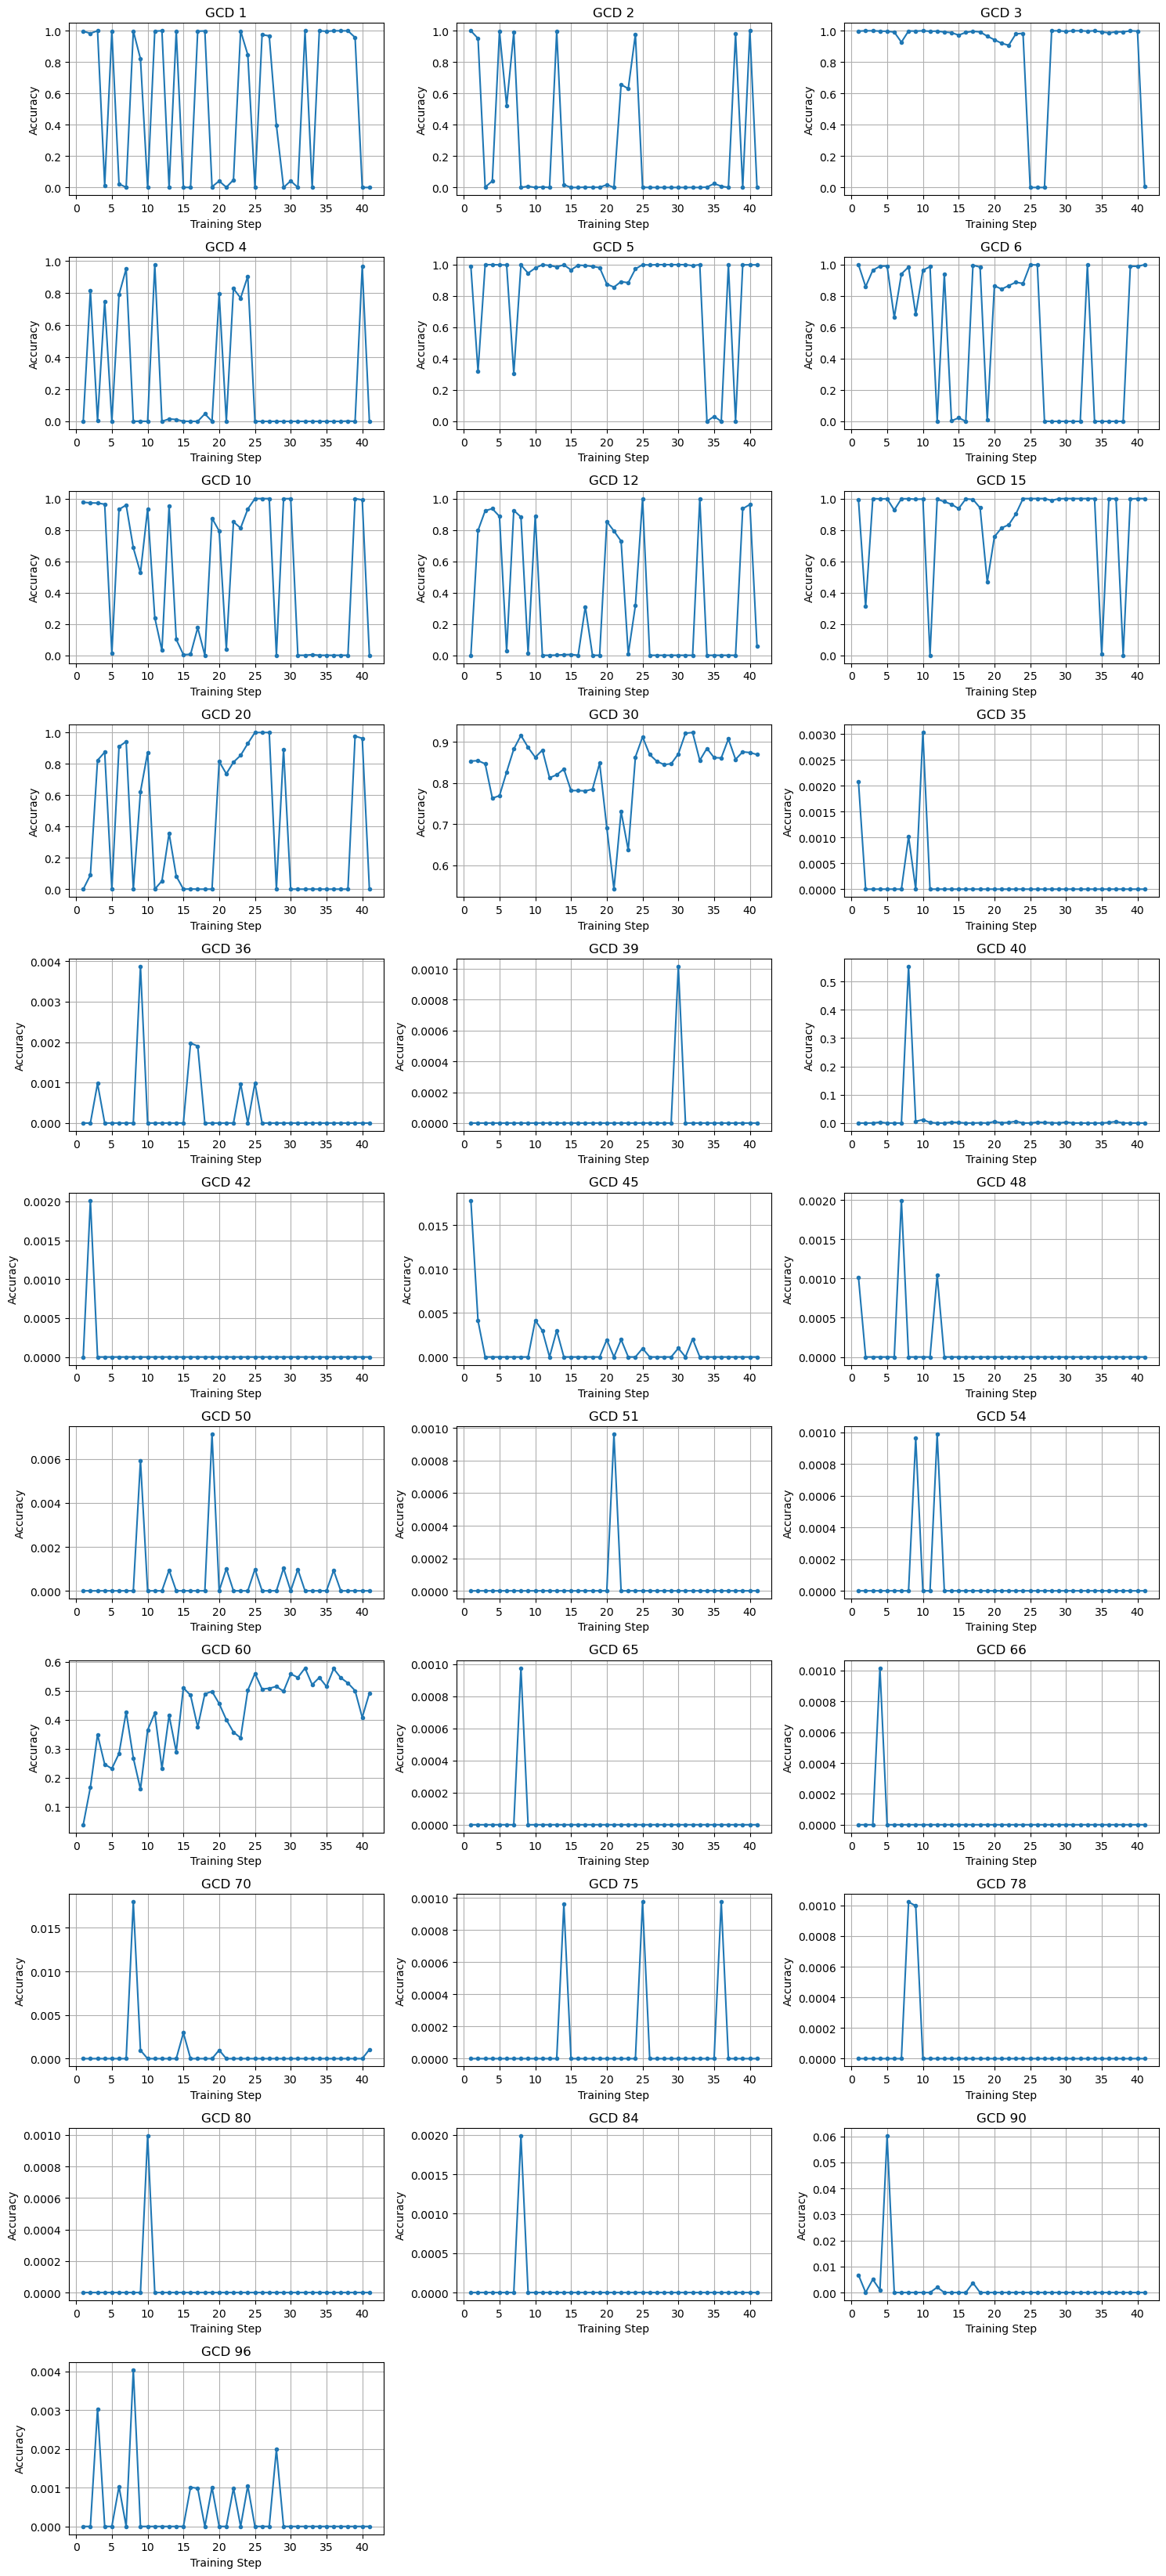

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Get the GCD columns (excluding 'step')
gcd_columns = per_gcd_df.columns.drop(['step'])

# Filter GCDs that have more than one unique value and sum > 1
valid_gcds = [gcd for gcd in gcd_columns 
              if len(np.unique(per_gcd_df[gcd])) > 1 and sum(per_gcd_df[gcd]) > 0]

# Determine the layout of subplots
n_gcds = len(valid_gcds)
n_cols = 3  # You can adjust this
n_rows = (n_gcds + n_cols - 1) // n_cols

# Create figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3*n_rows))
if n_gcds == 1:
    axes = np.array([axes])  # Ensure axes is always an array for consistency
axes = axes.flatten()  # Flatten for easy iteration

# Plot each GCD on its own subplot
for i, gcd in enumerate(valid_gcds):
    ax = axes[i]
    ax.plot(per_gcd_df['step'], per_gcd_df[gcd], marker='.')
    ax.set_title(f'GCD {gcd}')
    ax.set_xlabel("Training Step")
    ax.set_ylabel("Accuracy")
    ax.grid(True)

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
x = np.arange(1, 10)
y = 6 / (np.pi * x)**2
z = [sum(y[:int(i)]) for i in x]
fig, ax = plt.subplots(1, 2, figsize=(12,5))

ax[0].plot(x, y)
ax[1].plot(x, z)

ax[0].set_title("PMF of The Distribution of GCD")
ax[0].set_xlabel("GCD")
ax[0].set_ylabel("Probability")
ax[1].set_title("CMF of The Distribution of GCD")
ax[1].set_xlabel("GCD")
ax[1].set_ylabel("Probability")

In [11]:
# Initialize lists to store extracted values
losses = []
accuracies = []

# Read the file
with open('training_log.txt', 'r') as file:
    for line in file:
        line = line.strip()  # Remove leading/trailing whitespace
        if line:  # Skip empty lines
            # Split the line into components
            parts = line.split(', ')
            
            # Extract and convert loss value
            loss = float(parts[1].split(': ')[1])
            losses.append(loss)
            
            # Extract and convert accuracy value
            accuracy = float(parts[2].split(': ')[1])
            accuracies.append(accuracy)

# Print the results
print("Loss values:", losses)
print("\nAccuracy values:", accuracies)

Loss values: [0.5695522768517672, 0.2684045436523728, 0.22276068201004448, 0.2108989469075607, 0.1964447749620777, 0.19274699864751202, 0.19584017954135347, 0.183288452988964, 0.19108212038369501, 0.19699309602127238, 0.1928727803593975, 0.1924525009373487, 0.1955236010569132, 0.19465159056550366, 0.18843431859198262, 0.190657647863283, 0.18683111061484126, 0.19187942387188894, 0.1923190489158792, 0.18793664594828072, 0.19295275981648494, 0.18926495225247691, 0.19023052830312212, 0.1806611483758789, 0.18051697604231914, 0.17749563932923948, 0.16881009885820292, 0.17107260681815067, 0.16992828578262006, 0.1625111418760429, 0.15447729210353503, 0.15768804723175905, 0.14464127777491587, 0.14482925181924286, 0.1517307179964195, 0.1462553746493186, 0.1454201919042458, 0.14728946769136494, 0.1413163218205258, 0.14085607571622072, 0.14272998847951324, 0.14663885173908733, 0.1438272687906431, 0.14768731638284052, 0.14379664781992718, 0.14755002819633078, 0.14629942349205582, 0.1362811427374007

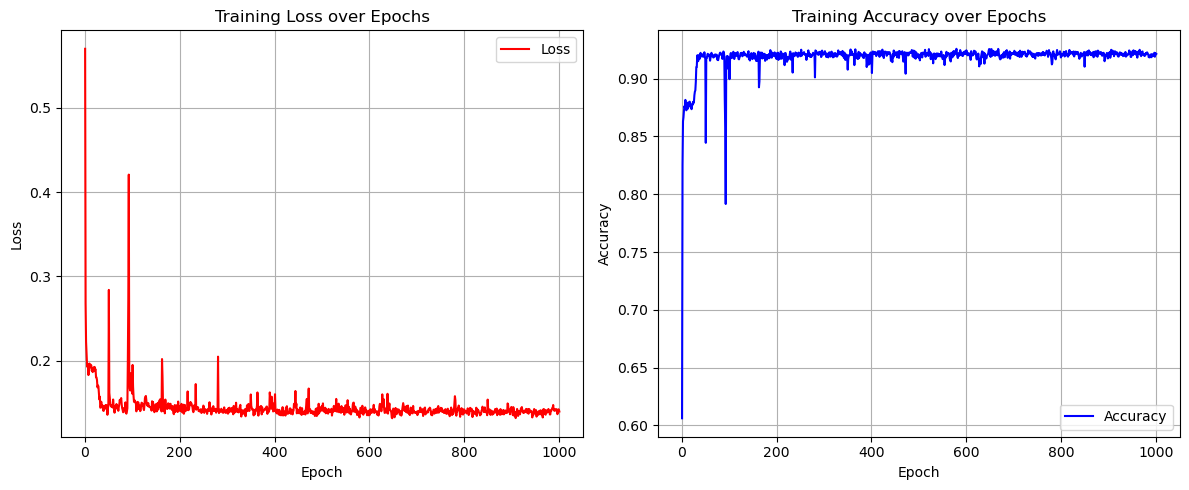

In [12]:
# Data (replace with your extracted lists)
epochs = list(range(1, max_epoch+1))
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, losses, 'r-', label='Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, accuracies, 'b-', label='Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy over Epochs')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()